In [33]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


# Customer Intelligence System using Classification, Ensemble Learning and Clustering

## Business Objective

HELP International wants to identify countries that require humanitarian aid the most. Using socio-economic and health indicators, we will segment countries and build predictive models to support data-driven decision making.

### Techniques Used
- K-Means Clustering
- DBSCAN Clustering
- Logistic Regression
- Random Forest
- XGBoost
- Feature Importance Analysis

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings_filter = __import__("warnings")
warnings_filter.filterwarnings("ignore")

# Dataset Loading

In [35]:
df = pd.read_csv(
    "/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Dataset Understanding

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [37]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [38]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Missing Values
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate Rows
0


# Exploratory Data Analysis (EDA)

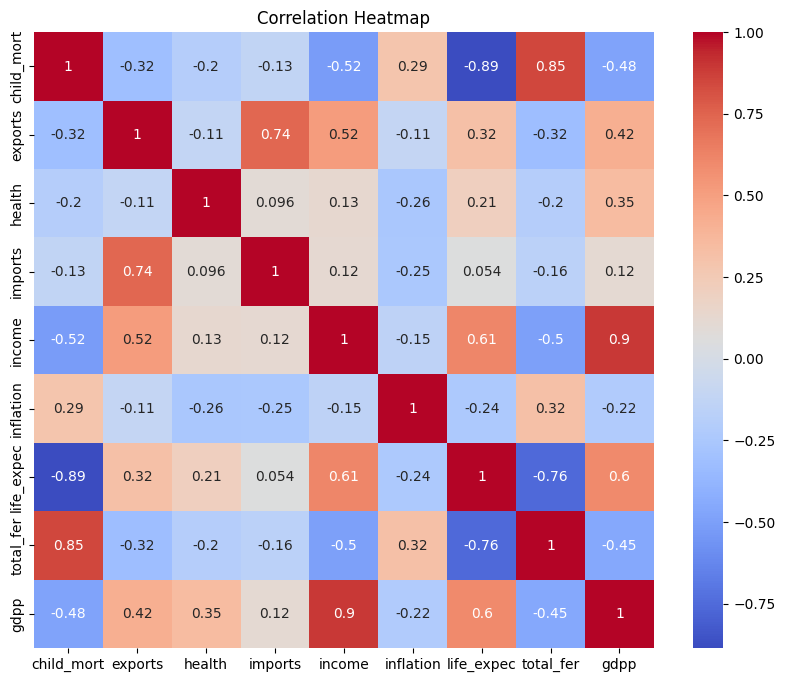

In [39]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("country", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

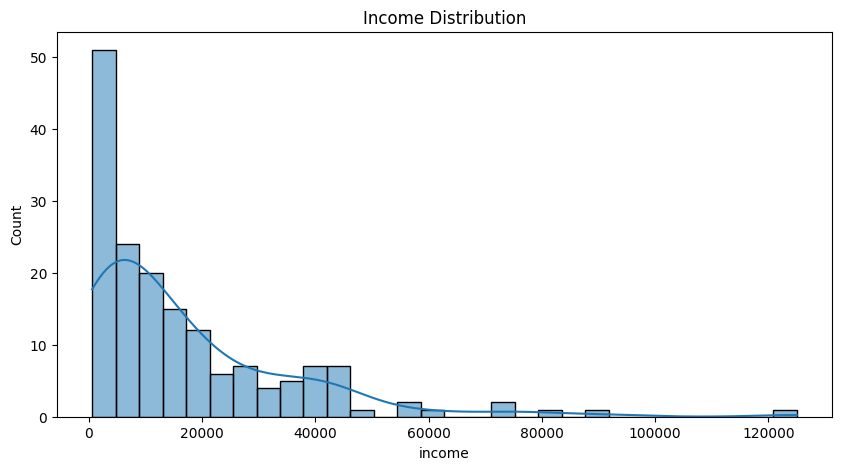

In [40]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["income"],
    bins=30,
    kde=True
)

plt.title("Income Distribution")
plt.show()

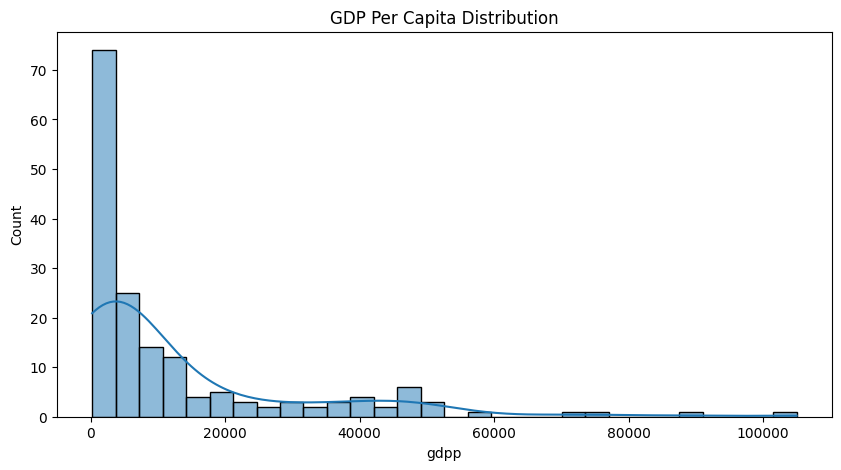

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["gdpp"],
    bins=30,
    kde=True
)

plt.title("GDP Per Capita Distribution")
plt.show()

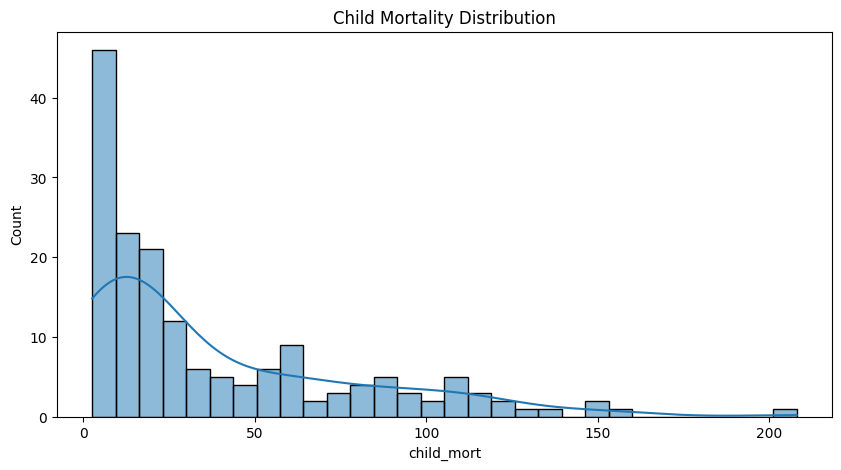

In [42]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["child_mort"],
    bins=30,
    kde=True
)

plt.title("Child Mortality Distribution")
plt.show()

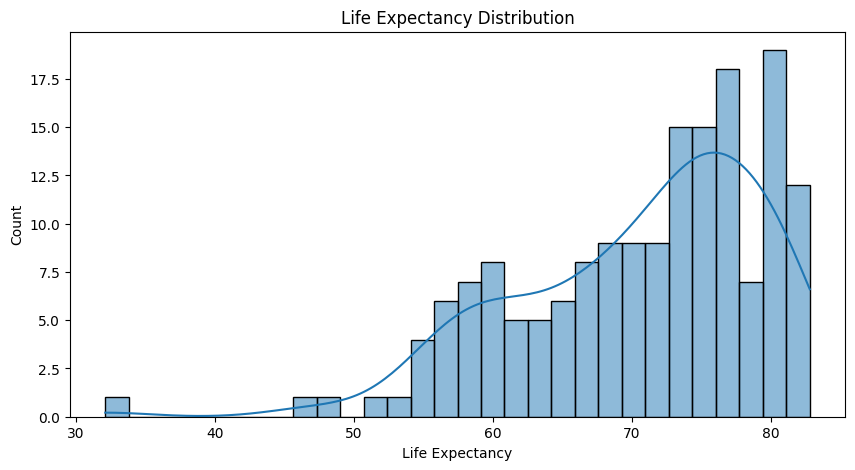

In [43]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["life_expec"],
    bins=30,
    kde=True
)

plt.title("Life Expectancy Distribution")
plt.xlabel("Life Expectancy")
plt.show()

# Outlier Analysis

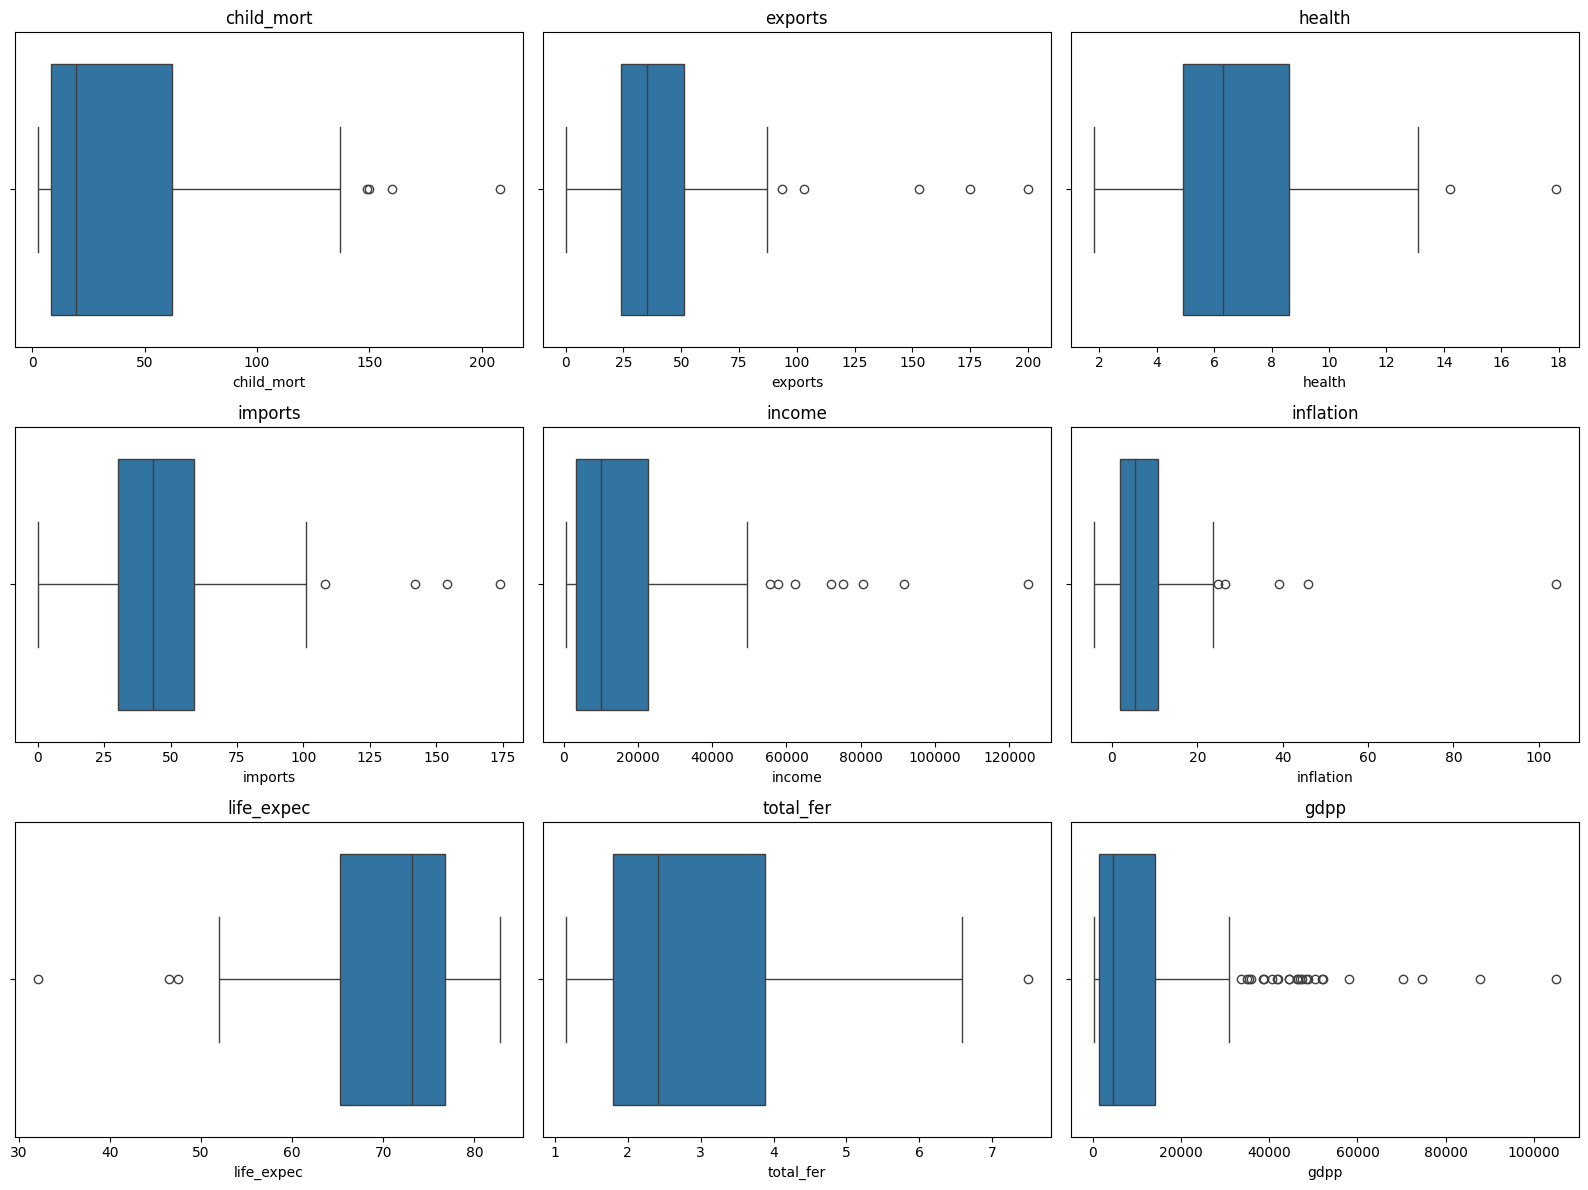

In [44]:
numerical_cols = df.drop(
    "country",
    axis=1
).columns

plt.figure(figsize=(16,12))

for i, col in enumerate(numerical_cols):

    plt.subplot(3,3,i+1)

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

# Data Preprocessing

In [45]:
country_names = df["country"]

features = df.drop(
    columns=["country"]
)

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    features
)

print("Scaled Data Shape:", scaled_features.shape)

Scaled Data Shape: (167, 9)


# K-Means Clustering

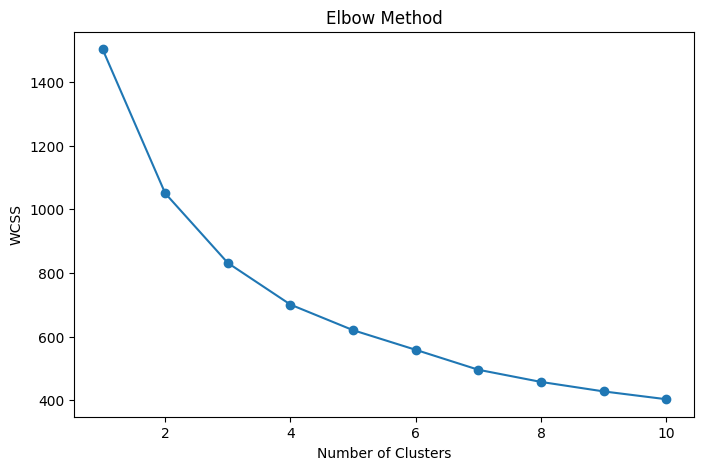

In [46]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [47]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    scaled_features
)

df["Cluster"] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [48]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled_features,
    clusters
)

print(
    "Silhouette Score:",
    round(score,3)
)

Silhouette Score: 0.283


In [49]:
cluster_summary = df.groupby(
    "Cluster"
).mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


# Cluster Interpretation

The cluster with the lowest income and GDP per capita, highest child mortality, and lowest life expectancy represents underdeveloped countries requiring humanitarian aid.

The cluster with the highest income, GDP per capita, and life expectancy represents developed countries.

The remaining cluster represents developing countries with moderate socio-economic conditions.

#  Cluster Visualization using PCA

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_features
)

pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = df["Cluster"]

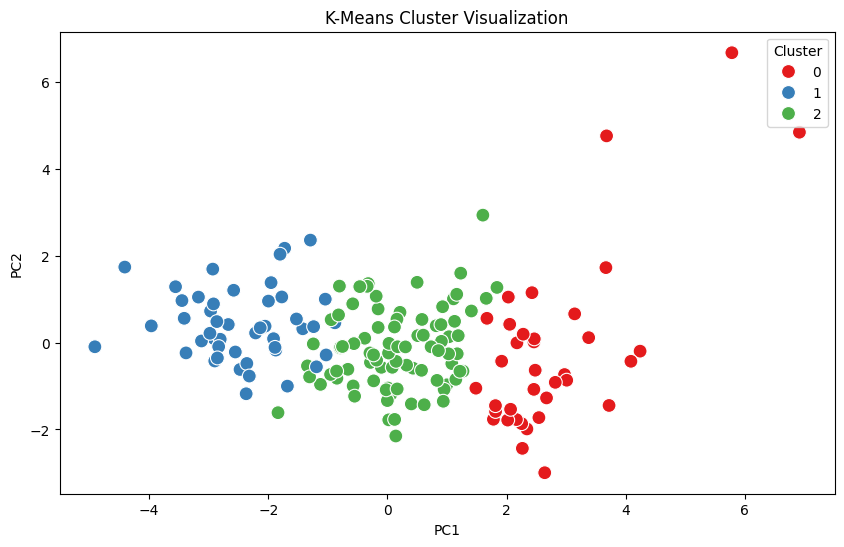

In [51]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("K-Means Cluster Visualization")
plt.show()

In [52]:
for cluster in sorted(df["Cluster"].unique()):

    print(f"\nTop Countries in Cluster {cluster}")

    display(
        df[df["Cluster"] == cluster][
            ["country","income","gdpp","life_expec"]
        ].head(10)
    )


Top Countries in Cluster 0


,country,income,gdpp,life_expec
7,Australia,41400,51900,82.0
8,Austria,43200,46900,80.5
11,Bahrain,41100,20700,76.0
15,Belgium,41100,44400,80.0
23,Brunei,80600,35300,77.1
29,Canada,40700,47400,81.3
42,Cyprus,33900,30800,79.9
43,Czech Republic,28300,19800,77.5
44,Denmark,44000,58000,79.5
53,Finland,39800,46200,80.0



Top Countries in Cluster 1


,country,income,gdpp,life_expec
0,Afghanistan,1610,553,56.2
3,Angola,5900,3530,60.1
17,Benin,1820,758,61.8
21,Botswana,13300,6350,57.1
25,Burkina Faso,1430,575,57.9
26,Burundi,764,231,57.7
28,Cameroon,2660,1310,57.3
31,Central African Republic,888,446,47.5
32,Chad,1930,897,56.5
36,Comoros,1410,769,65.9



Top Countries in Cluster 2


,country,income,gdpp,life_expec
1,Albania,9930,4090,76.3
2,Algeria,12900,4460,76.5
4,Antigua and Barbuda,19100,12200,76.8
5,Argentina,18700,10300,75.8
6,Armenia,6700,3220,73.3
9,Azerbaijan,16000,5840,69.1
10,Bahamas,22900,28000,73.8
12,Bangladesh,2440,758,70.4
13,Barbados,15300,16000,76.7
14,Belarus,16200,6030,70.4


# # DBSCAN Clustering

In [53]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_clusters = dbscan.fit_predict(
    scaled_features
)

df["DBSCAN_Cluster"] = dbscan_clusters

print(
    df["DBSCAN_Cluster"].value_counts()
)

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


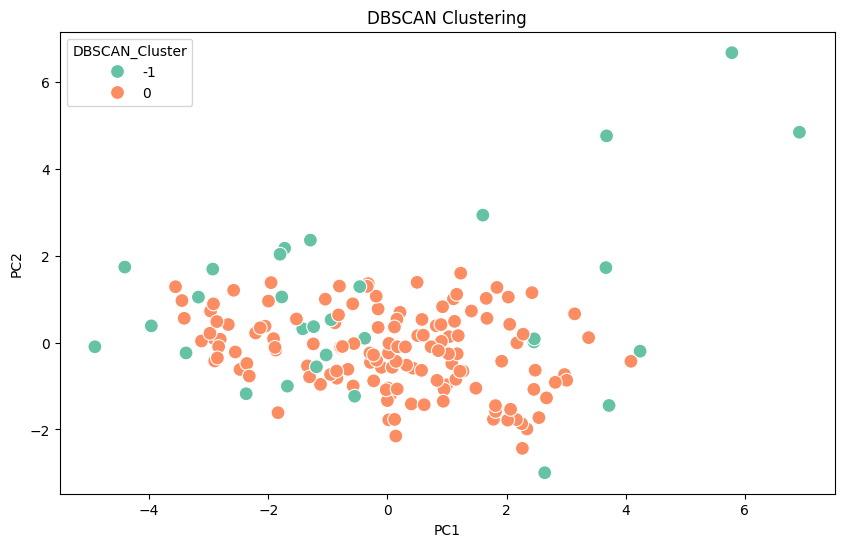

In [54]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=df["DBSCAN_Cluster"],
    palette="Set2",
    s=100
)

plt.title("DBSCAN Clustering")
plt.show()

# Classification Models

Cluster labels generated by K-Means are used as target classes. The objective is to build models capable of predicting the development category of a country based on socio-economic indicators.

In [55]:
X = scaled_features

y = df["Cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)

log_predictions = log_model.predict(
    X_test
)

log_accuracy = accuracy_score(
    y_test,
    log_predictions
)

print(
    "Logistic Regression Accuracy:",
    round(log_accuracy,4)
)

Logistic Regression Accuracy: 1.0


In [57]:
print(
    classification_report(
        y_test,
        log_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# Random Forest Classifier

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy,4)
)

Random Forest Accuracy: 1.0


In [59]:
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# XGBoost Classifier

In [60]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_test
)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print(
    "XGBoost Accuracy:",
    round(xgb_accuracy,4)
)

XGBoost Accuracy: 0.9412


In [61]:
print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



# Confusion Matrix

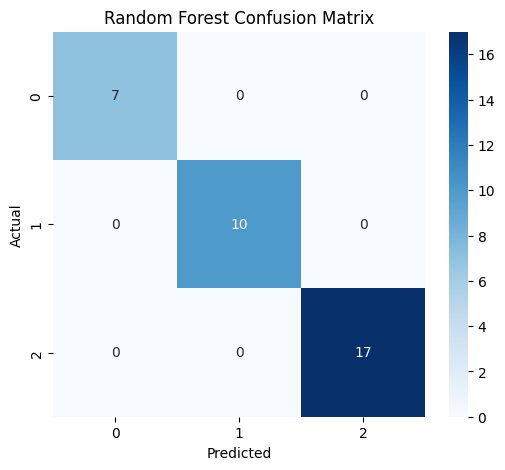

In [62]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(
        y_test,
        rf_predictions
    ),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Model Comparison

In [63]:
comparison_df = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        log_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,1.000000
1,Random Forest,1.000000
2,XGBoost,0.941176


# Feature Importance Analysis

In [64]:
importance_df = pd.DataFrame({
    "Feature":features.columns,
    "Importance":rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
0,child_mort,0.261935
8,gdpp,0.202125
7,total_fer,0.165920
6,life_expec,0.156307
4,income,0.146203
2,health,0.030472
5,inflation,0.014817
3,imports,0.012632
1,exports,0.009589


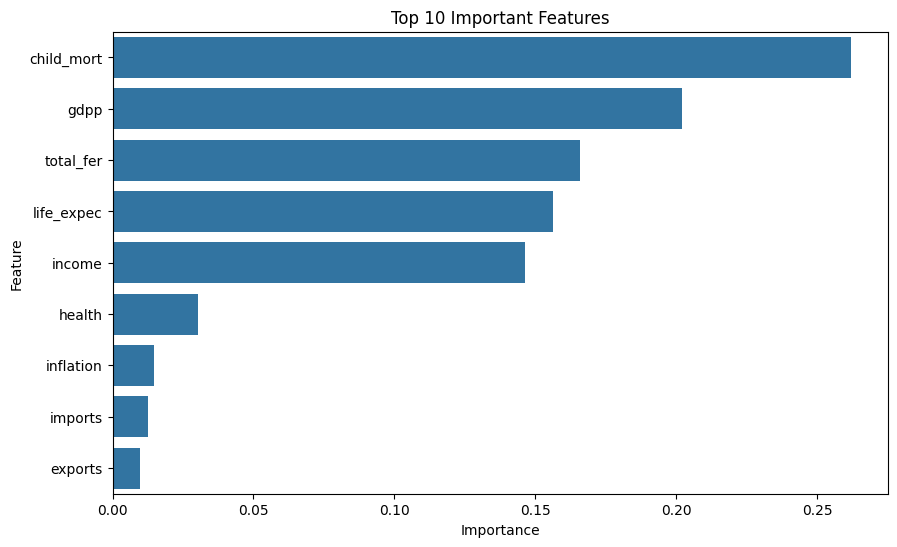

In [65]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

# Business Insights

In [66]:
high_risk_cluster = cluster_summary["income"].idxmin()

priority_countries = df[
    df["Cluster"] == high_risk_cluster
][["country","income","gdpp","child_mort"]]

priority_countries

,country,income,gdpp,child_mort
0,Afghanistan,1610,553,90.2
3,Angola,5900,3530,119.0
17,Benin,1820,758,111.0
21,Botswana,13300,6350,52.5
25,Burkina Faso,1430,575,116.0
26,Burundi,764,231,93.6
28,Cameroon,2660,1310,108.0
31,Central African Republic,888,446,149.0
32,Chad,1930,897,150.0
36,Comoros,1410,769,88.2


In [67]:
cluster_summary[
[
    "income",
    "gdpp",
    "child_mort",
    "life_expec"
]
]

,income,gdpp,child_mort,life_expec
Cluster,,,,
0,45672.222222,42494.444444,5.000000,80.127778
1,3942.404255,1922.382979,92.961702,59.187234
2,12305.595238,6486.452381,21.927381,72.814286


# Key Findings

1. K-Means clustering successfully grouped countries into development-based segments.

2. The high-risk cluster was characterized by low income levels, low GDP per capita, and high child mortality rates.

3. Countries such as Afghanistan, Burundi, Chad, Central African Republic, and Congo were identified as priority candidates for humanitarian assistance.

4. Logistic Regression and Random Forest achieved 100% classification accuracy, while XGBoost achieved approximately 94% accuracy.

5. Economic indicators and health-related factors played a major role in distinguishing country development levels.

6. The developed Customer Intelligence System provides a data-driven framework for prioritizing aid allocation.

# Conclusion

This project developed a Customer Intelligence System using clustering, classification, and ensemble learning techniques to support humanitarian decision-making.

K-Means and DBSCAN were used to segment countries based on socio-economic and health indicators. The clustering analysis identified a high-risk group of countries characterized by low income, low GDP per capita, and high child mortality.

The generated cluster labels were used to train classification models. Logistic Regression and Random Forest achieved perfect classification performance, while XGBoost also demonstrated strong predictive capability.

Based on the analysis, countries such as Afghanistan, Burundi, Chad, Central African Republic, and Congo should be prioritized for humanitarian aid and development programs.

The proposed system can assist HELP International in making data-driven and transparent resource allocation decisions.

# Final Insights

### 1. Which cluster has high child mortality?

The high-risk cluster identified through K-Means clustering showed the highest average child mortality rates. This indicates poor healthcare conditions and a greater need for humanitarian support.

### 2. Which cluster has high income and GDP per capita?

The developed cluster had the highest average income and GDP per capita values. Countries in this cluster represent economically strong and highly developed nations.

### 3. Which cluster looks underdeveloped?

The underdeveloped cluster was characterized by:
- Low income levels
- Low GDP per capita
- High child mortality
- Lower life expectancy

These indicators suggest significant socio-economic and healthcare challenges.

### 4. Which countries should be prioritized for aid?

Based on the clustering analysis, countries such as:

- Afghanistan
- Burundi
- Chad
- Central African Republic
- Congo
- Benin
- Burkina Faso
- Eritrea

were identified within the highest-risk cluster and should be prioritized for humanitarian aid and development programs.

### Overall Conclusion

The clustering analysis successfully segmented countries according to their socio-economic and health conditions. The results provide a data-driven framework for HELP International to identify vulnerable countries and allocate resources more effectively.